## Bibliotekos

Importuojamos reikalingos bibliotekos:
- **numpy** — skaitiniai skaičiavimai, matricos, atsitiktinių skaičių generavimas
- **pandas** — duomenų įkėlimas ir apdorojimas
- **matplotlib** — grafikų braižymas
- **time** — mokymo laiko matavimui

Nustatoma atsitiktinių skaičių pradinė reikšmė (`random_state=67`), kad rezultatai būtų atkartojami kiekvieną kartą paleidus kodą.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(67)

## Duomenų paruošimas

Naudojama **Breast Cancer Wisconsin (Original)** duomenų aibė iš UCI Machine Learning Repository.  
Duomenų aibėje yra **699 įrašai** ir **9 požymiai** (be ID ir klasės stulpelio).



Atliekami šie paruošimo žingsniai:
1. **Įkeliami duomenys** iš failo — stulpelių pavadinimai pridedami rankiniu būdu, nes faile nėra antraštės
2. **Išmetamas ID stulpelis** — jis neneša informacijos apie klasę
3. **Išmetamos eilutės su trūkstamomis reikšmėmis** — stulpelyje `x6` yra `?` simbolių (16 eilučių), po valymo lieka **683 įrašai**
4. **Pakeičiamos klasių žymės**: `2 → 0` (nepiktybinis navikas), `4 → 1` (piktybinis navikas)
5. **Permaišomos eilutės** atsitiktine tvarka — kad mokymo aibėje klasės būtų tolygiai išdėstytos
6. **Duomenys padalijami** santykiu **80/10/10**:
   - Mokymo aibė (~546 įrašai) — naudojama svorių mokymui
   - Validavimo aibė (~68 įrašai) — naudojama hiperparametrų parinkimui mokymo metu
   - Testavimo aibė (~69 įrašai) — naudojama galutiniam modelio įvertinimui, neliečiama mokymo metu
   

In [16]:
stulpeliai = ['id','x1','x2','x3','x4','x5','x6','x7','x8','x9','klase']

df = pd.read_csv('breast-cancer-wisconsin.data',
                 header=None, names=stulpeliai, na_values='?')

df = df.drop(columns=['id'])
df = df.dropna()
df = df.apply(pd.to_numeric, errors='coerce')
df['klase'] = df['klase'].map({2: 0, 4: 1})
df = df.sample(frac=1, random_state=69).reset_index(drop=True)

n = len(df)
mokymas    = df.iloc[:int(0.8*n)]
validavimas = df.iloc[int(0.8*n):int(0.9*n)]
testavimas  = df.iloc[int(0.9*n):]

print(f"Mokymas: {len(mokymas)}, Validavimas: {len(validavimas)}, Testavimas: {len(testavimas)}")

Mokymas: 546, Validavimas: 68, Testavimas: 69


## Pagalbinės funkcijos

Apibrėžiamos keturios pagalbinės funkcijos naudojamos visame kode:

**`sigmoid(a)`** — sigmoidinė aktyvacijos funkcija:
$$f(a) = \frac{1}{1 + e^{-a}}$$
Grąžina reikšmę intervale (0, 1). Kuo didesnė įėjimo reikšmė, tuo artimesnė 1.

**`neurono_isejimas(X, w, b)`** — apskaičiuoja neurono išėjimą visiems įrašams vienu metu:
$$a = X \cdot w + b, \quad y = \sigma(a)$$
Grąžina tęstinį išėjimą (sigmoid reikšmė) ir suapvalintą klasę (0 arba 1).

**`inicializuoti(n_pozymiu)`** — nustato pradines svorių reikšmes naudojant **Xavier inicializaciją**:
$$w_k \sim U\left(-\frac{1}{\sqrt{n}}, \frac{1}{\sqrt{n}}\right)$$
Ši strategija užtikrina, kad pradiniai svoriai nebūtų nei per dideli, nei per maži — tai padeda greičiau konverguoti.

**`mse(y_tikra, y_spejama)`** — vidutinė kvadratinė paklaida (Mean Squared Error):
$$E(W) = \frac{1}{m}\sum_{i=1}^{m}(t_i - y_i)^2$$

**`tikslumas(y_tikra, y_klase)`** — klasifikavimo tikslumas (accuracy):
$$\text{accuracy} = \frac{\text{teisingai klasifikuotų skaičius}}{\text{visų įrašų skaičius}}$$

In [17]:
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))


def neurono_isejimas(X, w, b):
    """Grąžina tęstinį išėjimą ir suapvalintą klasę"""
    isejimas = sigmoid(X @ w + b)
    klase = np.round(isejimas)
    return isejimas, klase


def inicializuoti(n_pozymiu):
    """Svoriai iš N(0, 1/sqrt(n)) — Xavier inicializacija"""
    np.random.seed(69)
    riba = 1.0 / np.sqrt(n_pozymiu)
    w = np.random.uniform(-riba, riba, n_pozymiu)
    b = np.random.uniform(-riba, riba)
    return w, b


def mse(y_tikra, y_spejama):
    return np.mean((y_tikra - y_spejama) ** 2)


def tikslumas(y_tikra, y_klase):
    return np.mean(y_tikra == y_klase)

## Paketinis gradientinis nusileidimas (Batch Gradient Descent)

**Paketinis gradientinis nusileidimas** — tai mokymo algoritmas, kurio metu svoriai atnaujinami **vieną kartą per epochą**, sukaupus gradientų sumą iš **visų** mokymo įrašų.

**Epocha** — vienas pilnas praėjimas per visus mokymo duomenis, po kurio atliekamas vienas svorių atnaujinimas.

Algoritmo schema:
1. Inicializuojami atsitiktiniai svoriai $W = (w_0, w_1, ..., w_n)$
2. Kiekvienoje epochoje:
   - Permaišomi mokymo duomenys
   - Einame per **visus** $m$ įrašus ir **kaupiame** gradientų sumą:
$$\text{gradientSum}_k = \sum_{i=1}^{m}(y_i - t_i) \cdot y_i \cdot (1 - y_i) \cdot x_{ik}$$
   - Tik po visų įrašų atnaujiname svorius:
$$w_k := w_k - \eta \cdot \frac{\text{gradientSum}_k}{m}$$
3. Kartojame kol pasiekiamas epochų skaičius arba paklaida mažesnė už ribą

**Privalumai:** stabili konvergencija, sklandus paklaidos mažėjimas  
**Trūkumai:** lėtas konvergavimas, reikia daug epochų pasiekti žemą paklaidą

In [18]:
def batch_gd(mokymas, validavimas, lr=0.1, epochos=500, riba=0.0):
   
    X_m = mokymas.iloc[:, :-1].values.astype(float)
    t_m = mokymas.iloc[:, -1].values
    X_v = validavimas.iloc[:, :-1].values.astype(float)
    t_v = validavimas.iloc[:, -1].values

    w, b = inicializuoti(X_m.shape[1])
    m = len(X_m)

    mse_mokymas, mse_val = [], []
    tiksl_mokymas, tiksl_val = [], []
    epocha = 0
    train_mse = np.inf

    while epocha < epochos and train_mse > riba:
        # Pirmyn praėjimas
        y, _ = neurono_isejimas(X_m, w, b)

        # Gradientas vektorizuotai
        delta = (y - t_m) * y * (1 - y)        # (m,)
        grad_w = X_m.T @ delta / m              # (n_pozymiu,)
        grad_b = delta.mean()

        # Svorių atnaujinimas
        w -= lr * grad_w
        b -= lr * grad_b

        # Statistikos
        y_m, kl_m = neurono_isejimas(X_m, w, b)
        y_v, kl_v = neurono_isejimas(X_v, w, b)

        mse_mokymas.append(mse(t_m, y_m))
        mse_val.append(mse(t_v, y_v))
        tiksl_mokymas.append(tikslumas(t_m, kl_m))
        tiksl_val.append(tikslumas(t_v, kl_v))

        train_mse = mse_mokymas[-1]
        epocha += 1

    print(f"[Batch GD] lr={lr} | Epochos: {epocha} | "
          f"Train MSE: {mse_mokymas[-1]:.4f} | Val MSE: {mse_val[-1]:.4f} | "
          f"Train tiksl.: {tiksl_mokymas[-1]:.4f} | Val tiksl.: {tiksl_val[-1]:.4f}")

    return dict(w=w, b=b, epochos=epocha, lr=lr,
                mse_mokymas=mse_mokymas, mse_val=mse_val,
                tiksl_mokymas=tiksl_mokymas, tiksl_val=tiksl_val)

##  Stochastinis gradientinis nusileidimas (Stochastic Gradient Descent)

**Stochastinis gradientinis nusileidimas (SGD)** — tai mokymo algoritmas, kurio metu svoriai atnaujinami **po kiekvieno įrašo** atskirai.

**Epocha** — vienas pilnas praėjimas per visus mokymo duomenis, per kurį svoriai atnaujinami $m$ kartų (po vieną kartą kiekvienam įrašui).

Algoritmo schema:
1. Inicializuojami atsitiktiniai svoriai
2. Kiekvienoje epochoje:
   - Permaišomi mokymo duomenys
   - Einame per **kiekvieną** įrašą $i$ ir **iš karto** atnaujiname svorius:
$$w_k := w_k - \eta \cdot (y_i - t_i) \cdot y_i \cdot (1 - y_i) \cdot x_{ik}$$
3. Kartojame kol pasiekiamas epochų skaičius arba paklaida mažesnė už ribą

**Privalumai:** greita konvergencija (žema paklaida pasiekiama jau po kelių epochų), gali išvengti lokalių minimumų dėl triukšmo  
**Trūkumai:** paklaidos kreivė svyruoja, jautresnė dideliam mokymosi greičiui

In [19]:
def sgd(mokymas, validavimas, lr=0.1, epochos=500, riba=0.0):
   
    X_m = mokymas.iloc[:, :-1].values.astype(float)
    t_m = mokymas.iloc[:, -1].values
    X_v = validavimas.iloc[:, :-1].values.astype(float)
    t_v = validavimas.iloc[:, -1].values

    w, b = inicializuoti(X_m.shape[1])
    m = len(X_m)

    mse_mokymas, mse_val = [], []
    tiksl_mokymas, tiksl_val = [], []
    epocha = 0
    train_mse = np.inf

    while epocha < epochos and train_mse > riba:
        indeksai = np.random.permutation(m)

        for i in indeksai:
            xi = X_m[i]
            ti = t_m[i]
            yi = sigmoid(xi @ w + b)

            delta = (yi - ti) * yi * (1 - yi)
            w -= lr * delta * xi
            b -= lr * delta

        y_m, kl_m = neurono_isejimas(X_m, w, b)
        y_v, kl_v = neurono_isejimas(X_v, w, b)

        mse_mokymas.append(mse(t_m, y_m))
        mse_val.append(mse(t_v, y_v))
        tiksl_mokymas.append(tikslumas(t_m, kl_m))
        tiksl_val.append(tikslumas(t_v, kl_v))

        train_mse = mse_mokymas[-1]
        epocha += 1

    print(f"[SGD] lr={lr} | Epochos: {epocha} | "
          f"Train MSE: {mse_mokymas[-1]:.4f} | Val MSE: {mse_val[-1]:.4f} | "
          f"Train tiksl.: {tiksl_mokymas[-1]:.4f} | Val tiksl.: {tiksl_val[-1]:.4f}")

    return dict(w=w, b=b, epochos=epocha, lr=lr,
                mse_mokymas=mse_mokymas, mse_val=mse_val,
                tiksl_mokymas=tiksl_mokymas, tiksl_val=tiksl_val)

## Testavimo funkcija

Funkcija `testuoti(rez, testavimas)` pritaiko jau **apmokytą neuroną** (su rastais svoriais `w` ir `b`) testavimo aibei, kuri **nebuvo naudota mokymo metu**.

Apskaičiuojama:
- **Testavimo MSE** — paklaida testavimo aibėje
- **Testavimo tikslumas** — procentas teisingai klasifikuotų įrašų
- Kiekvienam testavimo įrašui išvedama tikroji klasė, spėjama klasė ir ar klasifikuota teisingai

Testavimo aibė naudojama kaip **galutinis nepriklausomas įvertinimas** — ji niekada nebuvo rodyta neuronui mokymo ar validavimo metu, todėl jos rezultatai atspindi realų modelio gebėjimą klasifikuoti naujus duomenis.

In [20]:
def testuoti(rez, testavimas):
    X_t = testavimas.iloc[:, :-1].values.astype(float)
    t_t = testavimas.iloc[:, -1].values

    y_t, kl_t = neurono_isejimas(X_t, rez['w'], rez['b'])
    test_mse   = mse(t_t, y_t)
    test_tiksl = tikslumas(t_t, kl_t)

    print(f"Testavimo MSE:      {test_mse:.4f}")
    print(f"Testavimo tikslumas: {test_tiksl:.4f}\n")
    print(f"{'Nr.':<5} {'Tikroji':>10} {'Spėjama':>10} {'':>4}")
    print("-" * 32)
    for i in range(len(t_t)):
        zyme = "TEISINGAS" if kl_t[i] == t_t[i] else "NETEISINGAS"
        print(f"{i+1:<5} {int(t_t[i]):>10} {int(kl_t[i]):>10}  {zyme}")

    return test_mse, test_tiksl

## Grafikų funkcijos

Apibrėžiamos keturios vizualizacijos funkcijos:

**`grafikai_epochos(rez, pavadinimas)`**  
Braižo du grafikus šalia: MSE paklaidą ir tikslumą nuo epochų skaičiaus, atskirai mokymo ir validavimo duomenims. Leidžia stebėti kaip neuronas mokosi bėgant epochoms.

**`stulpeline_lr(rezultatai_dict, pavadinimas)`**  
Stulpelinė diagrama rodanti galutinę paklaidą ir tikslumą skirtingiems mokymosi greičiams. Leidžia vizualiai palyginti kaip `lr` reikšmė įtakoja mokymo rezultatą.

**`palyginti_metodus(rez_batch, rez_sgd)`**  
Braižo Batch GD ir SGD mokymo paklaidą ir tikslumą vienoje diagramoje. Leidžia aiškiai pamatyti skirtumus tarp dviejų algoritmų konvergavimo greičio ir stabilumo.

**`palyginti_laika(laikas_batch, laikas_sgd)`**  
Stulpelinė diagrama lyginanti abiejų metodų mokymo laiką sekundėmis esant vienodam epochų skaičiui.

In [21]:
def grafikai_epochos(rez, pavadinimas):
    ep = range(1, rez['epochos'] + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(pavadinimas)

    axes[0].plot(ep, rez['mse_mokymas'], label='Mokymas')
    axes[0].plot(ep, rez['mse_val'],     label='Validavimas')
    axes[0].set_xlabel('Epocha'); axes[0].set_ylabel('MSE')
    axes[0].set_title('Paklaida'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(ep, rez['tiksl_mokymas'], label='Mokymas')
    axes[1].plot(ep, rez['tiksl_val'],     label='Validavimas')
    axes[1].set_xlabel('Epocha'); axes[1].set_ylabel('Tikslumas')
    axes[1].set_title('Tikslumas'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def stulpeline_lr(rezultatai_dict, pavadinimas):
    """Stulpelinė diagrama MSE ir tikslumui pagal lr"""
    lrs = list(rezultatai_dict.keys())
    x = np.arange(len(lrs)); w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Mokymosi greičio įtaka – {pavadinimas}')

    tr_mse  = [rezultatai_dict[lr]['mse_mokymas'][-1] for lr in lrs]
    val_mse = [rezultatai_dict[lr]['mse_val'][-1]     for lr in lrs]
    axes[0].bar(x - w/2, tr_mse,  w, label='Mokymas',    color='steelblue')
    axes[0].bar(x + w/2, val_mse, w, label='Validavimas', color='darkorange')
    axes[0].set_xticks(x); axes[0].set_xticklabels([str(l) for l in lrs])
    axes[0].set_xlabel('lr'); axes[0].set_ylabel('MSE')
    axes[0].set_title('Paklaida'); axes[0].legend(); axes[0].grid(axis='y')

    tr_acc  = [rezultatai_dict[lr]['tiksl_mokymas'][-1] for lr in lrs]
    val_acc = [rezultatai_dict[lr]['tiksl_val'][-1]     for lr in lrs]
    axes[1].bar(x - w/2, tr_acc,  w, label='Mokymas',    color='steelblue')
    axes[1].bar(x + w/2, val_acc, w, label='Validavimas', color='darkorange')
    axes[1].set_xticks(x); axes[1].set_xticklabels([str(l) for l in lrs])
    axes[1].set_xlabel('lr'); axes[1].set_ylabel('Tikslumas')
    axes[1].set_title('Tikslumas'); axes[1].legend(); axes[1].grid(axis='y')

    plt.tight_layout()
    plt.show()


def palyginti_metodus(rez_batch, rez_sgd):
    """Batch vs SGD MSE ir tikslumas"""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Batch GD vs SGD')

    ep_b = range(1, rez_batch['epochos'] + 1)
    ep_s = range(1, rez_sgd['epochos']   + 1)

    axes[0].plot(ep_b, rez_batch['mse_mokymas'], label='Batch GD')
    axes[0].plot(ep_s, rez_sgd['mse_mokymas'],   label='SGD')
    axes[0].set_xlabel('Epocha'); axes[0].set_ylabel('MSE')
    axes[0].set_title('Mokymo paklaida'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(ep_b, rez_batch['tiksl_mokymas'], label='Batch GD')
    axes[1].plot(ep_s, rez_sgd['tiksl_mokymas'],   label='SGD')
    axes[1].set_xlabel('Epocha'); axes[1].set_ylabel('Tikslumas')
    axes[1].set_title('Mokymo tikslumas'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def palyginti_laika(laikas_batch, laikas_sgd):
    """Mokymo laiko palyginimas"""
    plt.figure(figsize=(6, 5))
    bars = plt.bar(['Batch GD', 'SGD'], [laikas_batch, laikas_sgd],
                   color=['steelblue', 'darkorange'])
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}s', ha='center')
    plt.ylabel('Laikas (s)')
    plt.title('Mokymo laiko palyginimas (500 epochų)')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

## Tyrimai

Atliekami tyrimai pagal užduoties reikalavimus:

**8.1 Pagrindinis paleidimas** — neuronas mokomas Batch GD ir SGD metodais su `lr=0.1`, 500 epochų. Braižomi paklaidos ir tikslumo grafikai nuo epochų.

**8.2 Mokymosi greičio tyrimas** — kiekvienas metodas paleidžiamas su trimis skirtingomis `lr` reikšmėmis: `0.01`, `0.1`, `0.3`. Rezultatai vaizduojami stulpelinėmis diagramomis, kad būtų lengva palyginti galutines reikšmes.

**8.3 Batch GD vs SGD palyginimas** — abu metodai vaizduojami vienoje diagramoje (su `lr=0.1`), kad būtų matomas konvergavimo greičio ir stabilumo skirtumas.

**8.4 Mokymo laiko palyginimas** — matuojamas kiekvieno metodo mokymo laikas esant vienodam epochų skaičiui (500). SGD yra lėtesnis dėl Python `for` ciklo per kiekvieną įrašą, Batch GD greičiau dėl numpy vektorizacijos.

[Batch GD] lr=0.1 | Epochos: 500 | Train MSE: 0.0726 | Val MSE: 0.0672 | Train tiksl.: 0.9304 | Val tiksl.: 0.9118
[SGD] lr=0.1 | Epochos: 500 | Train MSE: 0.0254 | Val MSE: 0.0006 | Train tiksl.: 0.9634 | Val tiksl.: 1.0000


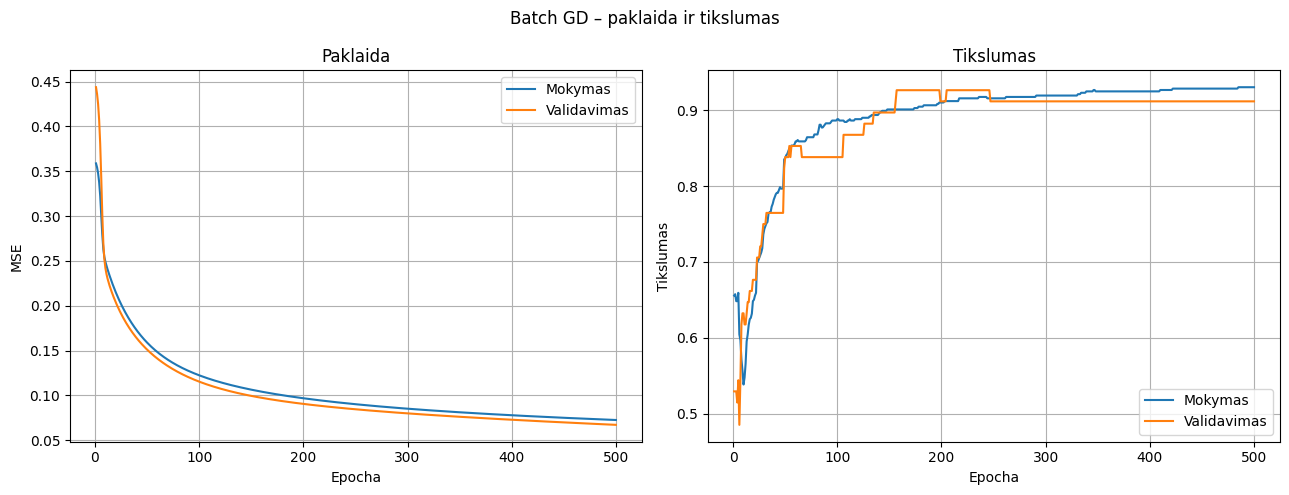

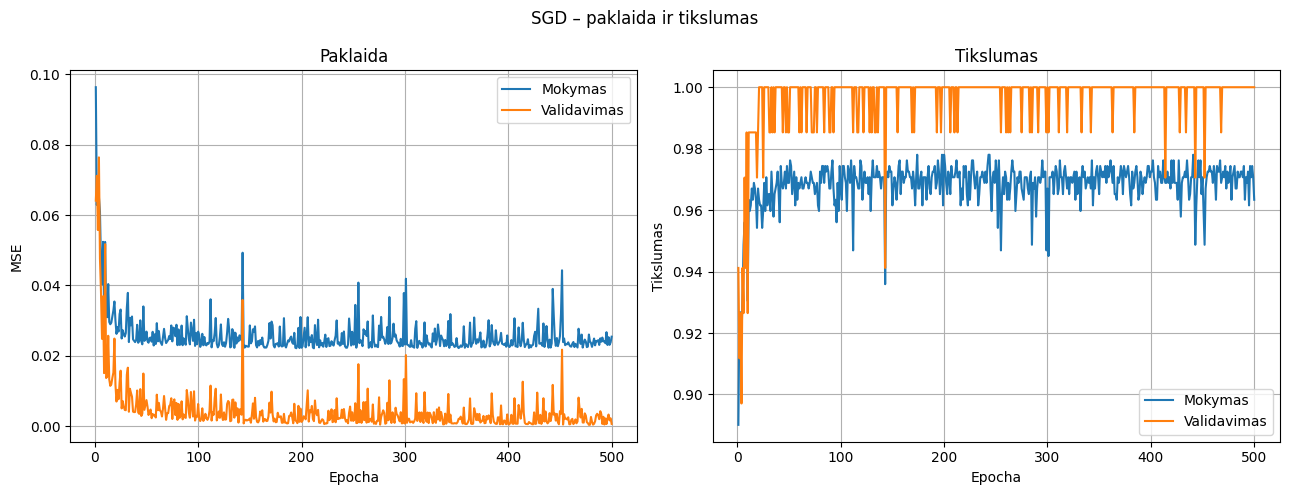

[Batch GD] lr=0.01 | Epochos: 500 | Train MSE: 0.1585 | Val MSE: 0.1506 | Train tiksl.: 0.8407 | Val tiksl.: 0.8382
[Batch GD] lr=0.1 | Epochos: 500 | Train MSE: 0.0726 | Val MSE: 0.0672 | Train tiksl.: 0.9304 | Val tiksl.: 0.9118
[Batch GD] lr=0.3 | Epochos: 500 | Train MSE: 0.0490 | Val MSE: 0.0384 | Train tiksl.: 0.9542 | Val tiksl.: 0.9559
[SGD] lr=0.01 | Epochos: 500 | Train MSE: 0.0234 | Val MSE: 0.0039 | Train tiksl.: 0.9670 | Val tiksl.: 1.0000
[SGD] lr=0.1 | Epochos: 500 | Train MSE: 0.0254 | Val MSE: 0.0006 | Train tiksl.: 0.9634 | Val tiksl.: 1.0000
[SGD] lr=0.3 | Epochos: 500 | Train MSE: 0.0265 | Val MSE: 0.0041 | Train tiksl.: 0.9707 | Val tiksl.: 0.9853


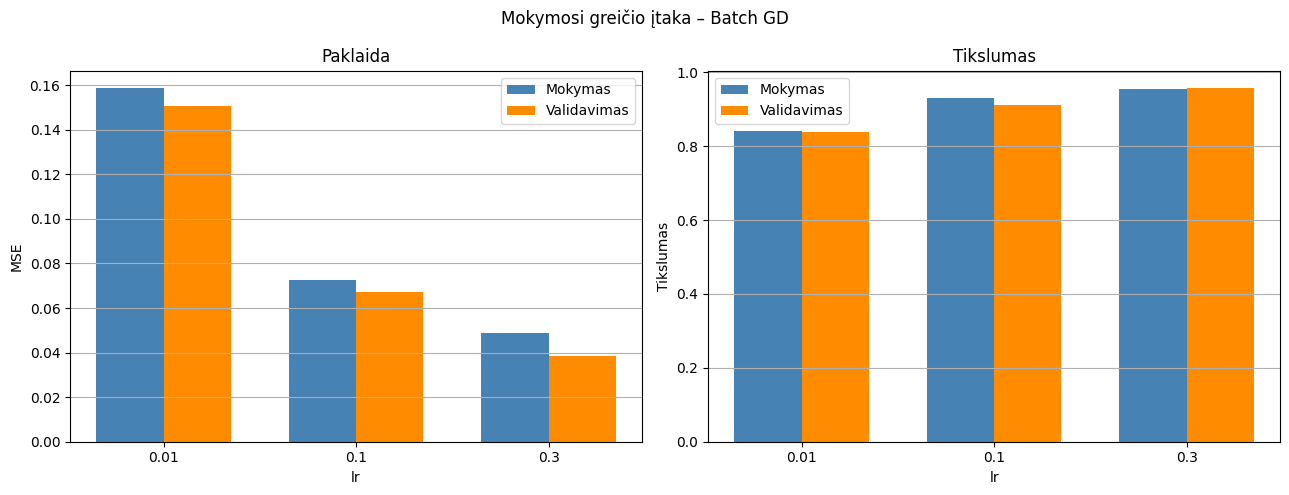

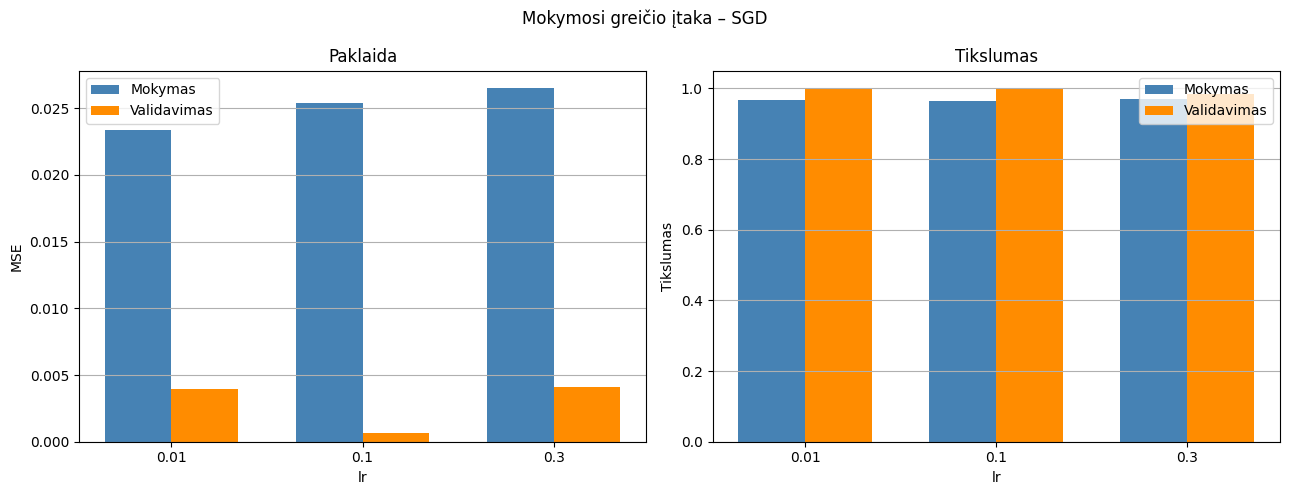

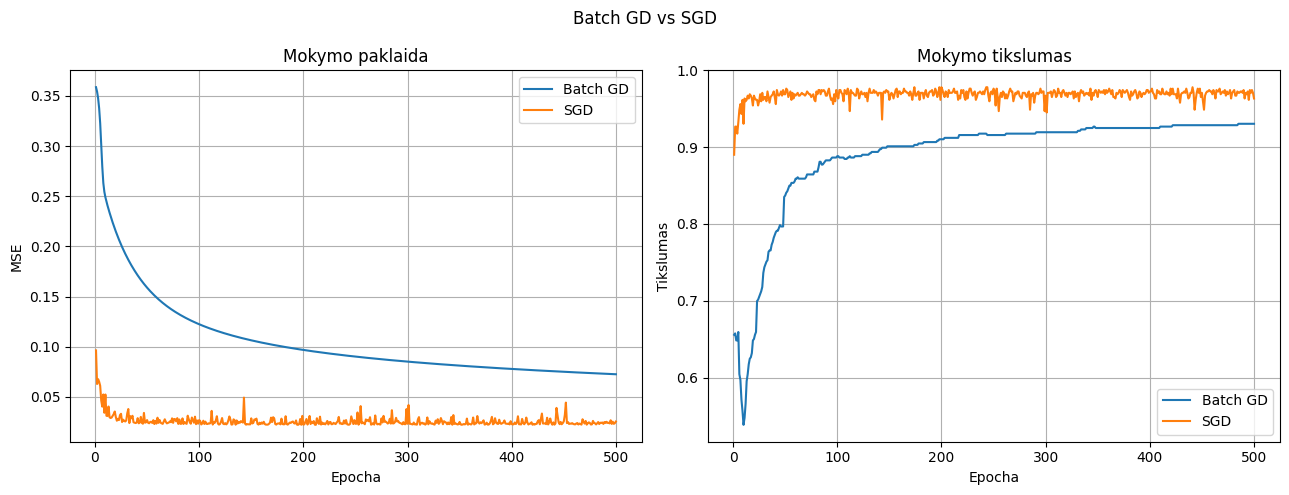

[Batch GD] lr=0.1 | Epochos: 500 | Train MSE: 0.0726 | Val MSE: 0.0672 | Train tiksl.: 0.9304 | Val tiksl.: 0.9118
[SGD] lr=0.1 | Epochos: 500 | Train MSE: 0.0254 | Val MSE: 0.0006 | Train tiksl.: 0.9634 | Val tiksl.: 1.0000


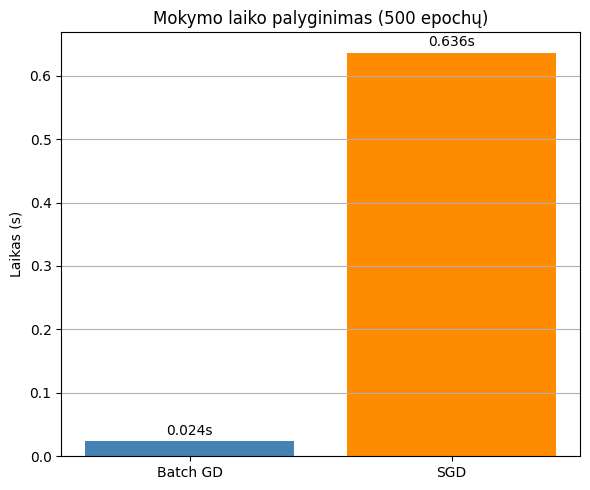

Batch GD laikas: 0.024s | SGD laikas: 0.636s


In [22]:
# ── Pagrindinis paleidimas ──────────────────────────────────
rez_batch = batch_gd(mokymas, validavimas, lr=0.1, epochos=500)
rez_sgd   = sgd(mokymas, validavimas,      lr=0.1, epochos=500)

grafikai_epochos(rez_batch, 'Batch GD – paklaida ir tikslumas')
grafikai_epochos(rez_sgd,   'SGD – paklaida ir tikslumas')

# ── Mokymosi greičio tyrimas ────────────────────────────────
learning_rates = [0.01, 0.1, 0.3]

lr_batch = {lr: batch_gd(mokymas, validavimas, lr=lr, epochos=500) for lr in learning_rates}
lr_sgd   = {lr: sgd(mokymas, validavimas,      lr=lr, epochos=500) for lr in learning_rates}

stulpeline_lr(lr_batch, 'Batch GD')
stulpeline_lr(lr_sgd,   'SGD')

# ── Batch vs SGD palyginimas ────────────────────────────────
palyginti_metodus(rez_batch, rez_sgd)

# ── Mokymo laikas ───────────────────────────────────────────
t0 = time.time(); batch_gd(mokymas, validavimas, lr=0.1, epochos=500); laikas_b = time.time()-t0
t0 = time.time(); sgd(mokymas, validavimas,      lr=0.1, epochos=500); laikas_s = time.time()-t0

palyginti_laika(laikas_b, laikas_s)
print(f"Batch GD laikas: {laikas_b:.3f}s | SGD laikas: {laikas_s:.3f}s")

## Geriausias modelis ir galutiniai rezultatai

Pasirenkamas geriausias modelis pagal **validavimo tikslumą ir paklaidą**.  


Pateikiami galutiniai rezultatai:
- Gauti **9 svoriai** ir **poslinkis (bias)**
- Paklaida ir tikslumas mokymo bei validavimo duomenims paskutinėje epochoje
- **Testavimo MSE** ir **testavimo tikslumas** — galutinis nepriklausomas modelio įvertinimas
- Kiekvieno testavimo įrašo tikroji ir spėjama klasė

In [23]:
geriausias = rez_sgd

print("=== Galutiniai svoriai ===")
print(f"w = {np.round(geriausias['w'], 4)}")
print(f"b = {geriausias['b']:.4f}\n")

test_mse, test_tiksl = testuoti(geriausias, testavimas)

=== Galutiniai svoriai ===
w = [ 0.646   0.4032  0.4363  0.4203 -0.0616  0.6681  0.2265  0.2622  0.8697]
b = -13.0539

Testavimo MSE:      0.0166
Testavimo tikslumas: 0.9855

Nr.      Tikroji    Spėjama     
--------------------------------
1              1          1  TEISINGAS
2              1          1  TEISINGAS
3              1          1  TEISINGAS
4              0          0  TEISINGAS
5              0          0  TEISINGAS
6              0          0  TEISINGAS
7              0          0  TEISINGAS
8              0          0  TEISINGAS
9              1          1  TEISINGAS
10             1          1  TEISINGAS
11             1          1  TEISINGAS
12             0          0  TEISINGAS
13             0          0  TEISINGAS
14             1          1  TEISINGAS
15             0          0  TEISINGAS
16             0          0  TEISINGAS
17             0          0  TEISINGAS
18             0          0  TEISINGAS
19             1          1  TEISINGAS
20             0  